### Importación de Librerías y Configuración

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import joblib

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Rutas del proyecto
BASE_DIR = Path("..")
RAW_DATA_PATH = BASE_DIR / "data" / "raw"
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed"

# Crear directorio procesado si no existe
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)
print("✅ Librerías cargadas y rutas configuradas correctamente.")

✅ Librerías cargadas y rutas configuradas correctamente.


### Carga de Datos Crudos
Nota sobre el Dataset: El archivo elliptic_txs_features.csv no tiene encabezado. La primera columna es el txId, la segunda es el paso de tiempo (time_step de 1 a 49) y las siguientes 165 columnas son características numéricas de la transacción.

In [2]:
# 1. Cargar clases
df_classes = pd.read_csv(RAW_DATA_PATH / "elliptic_txs_classes.csv")

# 2. Cargar features (sin header)
# Columna 0: txId | Columna 1: time_step | Columnas 2-166: features (165 en total)
df_features = pd.read_csv(RAW_DATA_PATH / "elliptic_txs_features.csv", header=None)

# Renombrar las dos primeras columnas de features
feature_cols = [f"feature_{i}" for i in range(df_features.shape[1] - 2)]
df_features.columns = ["txId", "time_step"] + feature_cols

print(f"Dataset de clases: {df_classes.shape}")
print(f"Dataset de características: {df_features.shape}")

Dataset de clases: (203769, 2)
Dataset de características: (203769, 167)


### Unificación y Exploración Inicial (EDA)

In [3]:
# Unir dataset de clases y características mediante txId
df_full = pd.merge(df_features, df_classes, on="txId")

# Verificar valores nulos
print("🔍 Cantidad de valores nulos en el dataset:", df_full.isnull().sum().sum())

# Mapeo de clases para legibilidad
# 1: Ilícita (Fraud), 2: Lícita (Normal), unknown: Sin etiquetar
class_map = {'1': 'Ilícita (1)', '2': 'Lícita (2)', 'unknown': 'Desconocida'}
df_full['class_label'] = df_full['class'].map(class_map)

# Distribución general de clases
print("\n📊 Distribución de Clases:")
print(df_full['class_label'].value_counts(dropna=False))

🔍 Cantidad de valores nulos en el dataset: 0

📊 Distribución de Clases:
class_label
Desconocida    157205
Lícita (2)      42019
Ilícita (1)      4545
Name: count, dtype: int64


### Visualización de Clases y Pasos de Tiempo

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_10808\3149496459.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_full, x='class_label', palette='viridis', ax=axes[0])


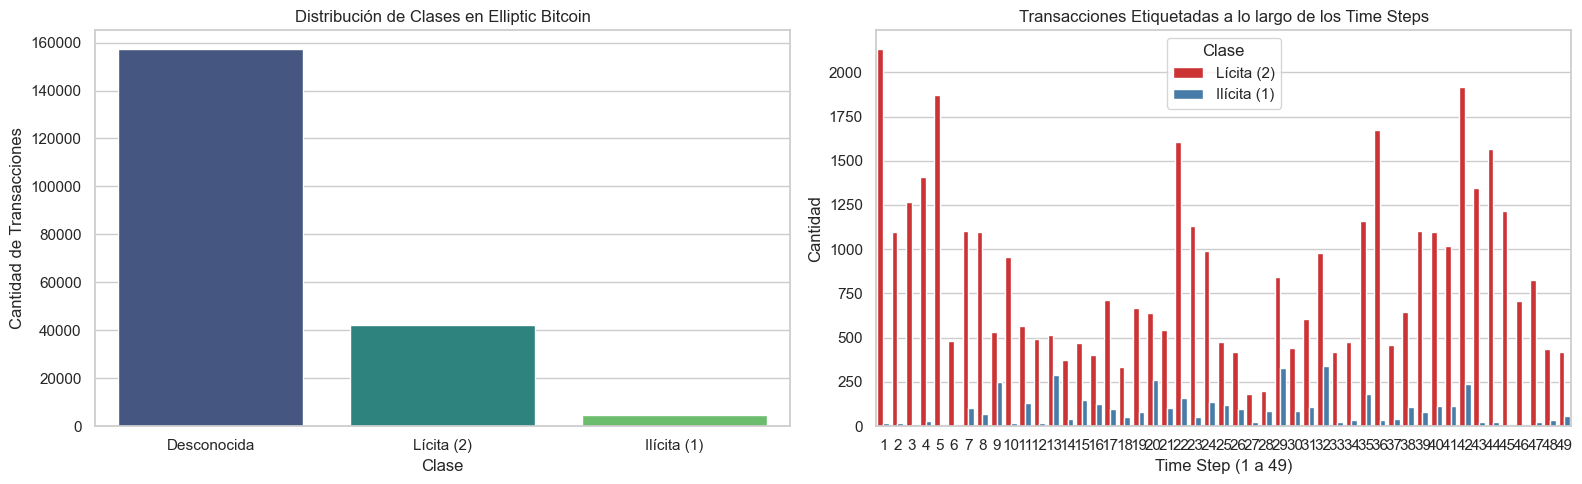

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Conteo de clases
sns.countplot(data=df_full, x='class_label', palette='viridis', ax=axes[0])
axes[0].set_title("Distribución de Clases en Elliptic Bitcoin")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad de Transacciones")

# Gráfico 2: Evolución temporal por clase
df_labeled = df_full[df_full['class'] != 'unknown']
sns.countplot(data=df_labeled, x='time_step', hue='class_label', palette='Set1', ax=axes[1])
axes[1].set_title("Transacciones Etiquetadas a lo largo de los Time Steps")
axes[1].set_xlabel("Time Step (1 a 49)")
axes[1].set_ylabel("Cantidad")
axes[1].legend(title="Clase")

plt.tight_layout()
plt.show()

### Filtrado y Estrategia del Autoencoder
Para la detección de anomalías con enfoque no supervisado:

Filtrar unknown: Nos quedamos solo con datos etiquetados (class1 y class2).

División Temporal (Train / Test Split):

Entrenamiento: Usamos transacciones de los time_steps 1 a 34 únicamente de la clase Lícita (class2).

Prueba/Validación: Usamos transacciones de los time_steps 35 a 49 con ambas clases (Lícita e Ilícita) para evaluar la capacidad de detectar anomalías.

In [5]:
# Filtrar fuera los datos desconocidos
df_labeled = df_full[df_full['class'].isin(['1', '2'])].copy()

# Mapear clase a binario para evaluación (0: Lícita / Normal, 1: Ilícita / Anomalía)
df_labeled['target'] = df_labeled['class'].apply(lambda x: 1 if x == '1' else 0)

# Split Temporal (Garantiza prevenir Data Leakage temporal)
train_mask = df_labeled['time_step'] <= 34
test_mask = df_labeled['time_step'] > 34

# 1. Dataset de prueba (contiene 0s y 1s)
df_test = df_labeled[test_mask]

# 2. Dataset de entrenamiento (FILTRADO EXCLUSIVAMENTE para Clase Lícita: target == 0)
df_train_licit = df_labeled[train_mask & (df_labeled['target'] == 0)]

print(f"Muestras de Entrenamiento (Solo Lícitas): {len(df_train_licit)}")
print(f"Muestras de Prueba (Lícitas + Ilícitas): {len(df_test)}")
print(f"  └─ Lícitas en Test: {(df_test['target'] == 0).sum()}")
print(f"  └─ Ilícitas en Test: {(df_test['target'] == 1).sum()}")

Muestras de Entrenamiento (Solo Lícitas): 26432
Muestras de Prueba (Lícitas + Ilícitas): 16670
  └─ Lícitas en Test: 15587
  └─ Ilícitas en Test: 1083


### Normalización y Escalado ($z$-score)
Importante: El scaler se ajusta (fit) únicamente con el conjunto de entrenamiento de transacciones lícitas para asegurar que el modelo aprenda la distribución normal sin contaminación de información del test set.

In [6]:
# Seleccionar solo las columnas de características numéricas
feature_columns = [col for col in df_labeled.columns if col.startswith("feature_")]

X_train = df_train_licit[feature_columns].values
X_test = df_test[feature_columns].values
y_test = df_test['target'].values

# Ajustar StandardScaler solo en Train Lícito
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transformar el conjunto de Test con el mismo scaler
X_test_scaled = scaler.transform(X_test)

print(f"Dimensión X_train_scaled: {X_train_scaled.shape}")
print(f"Dimensión X_test_scaled: {X_test_scaled.shape}")

Dimensión X_train_scaled: (26432, 165)
Dimensión X_test_scaled: (16670, 165)


### Guardar Artefactos Procesados

In [7]:
# Guardar matrices procesadas
np.save(PROCESSED_DATA_PATH / "X_train_licit.npy", X_train_scaled)
np.save(PROCESSED_DATA_PATH / "X_test.npy", X_test_scaled)
np.save(PROCESSED_DATA_PATH / "y_test.npy", y_test)

# Guardar el scaler entrenado para inferencias futuras
joblib.dump(scaler, PROCESSED_DATA_PATH / "scaler.joblib")

print("💾 ¡Archivos procesados guardados con éxito en data/processed/!")
print("  - X_train_licit.npy")
print("  - X_test.npy")
print("  - y_test.npy")
print("  - scaler.joblib")

💾 ¡Archivos procesados guardados con éxito en data/processed/!
  - X_train_licit.npy
  - X_test.npy
  - y_test.npy
  - scaler.joblib
